In [2]:
!hostname

node107


In [12]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

## Get participant data for current pipeline

In [171]:
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_azim_elev_v00/'
exp_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_azim_elev_v00/'
results = list(Path(result_path).glob('*.csv'))
manifests = list(Path(exp_manifest_path).glob('*pilot_meta.pkl'))


old_result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_azim_elev_exp/'
old_results = list(Path(old_result_path).glob('*.csv'))
results += old_results

old_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_v02/'
old_manifests =  sorted(list(Path(old_manifest_path).glob('*pilot_azimiuth_expt_v02_meta.pkl')))
manifests += [old_manifests[0]]


# add elev only conditions 
elev_result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/elev_pilot/'
elev_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/elev_pilot/'
elev_results = list(Path(elev_result_path).glob('*.csv'))
elev_manifests =  sorted(list(Path(elev_manifest_path).glob('*pilot_azimiuth_expt_v02_meta.pkl')))
results += elev_results
manifests += elev_manifests


In [172]:
results


[PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_azim_elev_v00/participant_001.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_azim_elev_v00/participant_002.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_azim_elev_exp/participant_001.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/elev_pilot/participant_001.csv'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/elev_pilot/participant_002.csv')]

In [173]:
manifests

[PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_azim_elev_v00/participant_001_pilot_meta.pkl'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_azim_elev_v00/participant_002_pilot_meta.pkl'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_v02/participant_001_pilot_azimiuth_expt_v02_meta.pkl'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/elev_pilot/participant_001_pilot_azimiuth_expt_v02_meta.pkl'),
 PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/elev_pilot/participant_002_pilot_azimiuth_expt_v02_meta.pkl')]

In [202]:
## Get all participant data into one df for analysis
def get_part_df(fname):
    part_df = pd.read_csv(fname)
    part_df = part_df[part_df.trial_type == 'dictionary-text'].reset_index(drop=True)
    part_df.trial_num = part_df.trial_num.astype(float).astype('int')
    # part_df['participant'] = fname.stem
    return part_df


def get_manifest_df(fname):
    manifest = pd.read_pickle(fname)
    manifest_df = pd.concat([pd.DataFrame(val.values()) for val in manifest.values()]).reset_index(drop=True)
    manifest_df['trial_num'] = manifest_df.index
    # unpack locations to azimuth and elevation 
    manifest_df['target_azim'] = manifest_df['target_loc'].apply(lambda x: x[0])
    manifest_df['target_elev'] = manifest_df['target_loc'].apply(lambda x: x[1])
    manifest_df['distractor_azim'] = manifest_df['distractor_loc'].apply(lambda x: x[0])
    manifest_df['distractor_elev'] = manifest_df['distractor_loc'].apply(lambda x: x[1])
    return manifest_df

def get_info_from_trial_dict(fname):
    manifest = pd.read_pickle(fname)
    trials = []
    for ix, trial in enumerate(manifest):
        trial_dict = {}
        trial_dict['target_azim'] = trial[0][0]
        trial_dict['target_elev'] = trial[0][1]
        trial_dict['distractor_azim'] = trial[1][0]
        trial_dict['distractor_elev'] = trial[1][1]
        trial_dict['target_word'] = Path(trial[3]).stem.split('_')[0]
        trial_dict['distractor_word'] = Path(trial[4]).stem.split('_')[0]
        trial_dict['trial_num'] = ix
        trials.append(trial_dict)
    manifest_df = pd.DataFrame(trials)
    return manifest_df
        

dfs = []
for ix, (fname, manifest) in enumerate(zip(results, manifests)):
    # try:
    part_name = manifest.stem 
    part_df = get_part_df(fname)
    manifest_df = get_manifest_df(manifest)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='right')
    part_df['participant'] = f"part_{ix}"
    dfs.append(part_df)
        # drop columns that are not useful for analysis
        # part_df.drop(['stimulus', 'trial_type', 'time_elapsed', 'internal_node_id', 'Unnamed: 0'], axis=1, inplace=True)
    # except Exception as e:
    #     print(e)
    #     print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs, ignore_index=True)

# add confusions
results_df['confusions'] = (results_df['response'] == results_df['distractor_word']).astype(int)

def same_diff_sex(string):
    target, distractor = string.split('_')
    if target == distractor:
        return 'same'
    else:
        return 'different'

results_df['gender_cond'] = results_df['sex_cond'].apply(same_diff_sex)

results_df['abs_target_azim'] = results_df['target_azim'].abs()

# make numerical columns same type
results_df['correct'] = results_df['correct'].astype('float')

In [205]:
results_df.head()

,trial_num,response,correct_response,correct,target_loc,distractor_loc,sex_cond,crossed,azim_delta,elev_delta,target_word,distractor_word,target_azim,target_elev,distractor_azim,distractor_elev,participant,confusions,gender_cond,abs_target_azim
0,0,limited,limited,1.0,"(-30, 0)","(0, 0)",male_female,1,30,0,limited,search,-30,0,0,0,part_0,0,different,30
1,1,probably,probably,1.0,"(0, 0)","(60, 0)",female_male,1,60,0,probably,trains,0,0,60,0,part_0,0,different,0
2,2,cross,across,0.0,"(30, 0)","(30, 0)",male_female,1,0,0,across,twenty,30,0,30,0,part_0,0,different,30
3,3,experience,experience,1.0,"(30, 0)","(60, 0)",female_male,1,30,0,experience,between,30,0,60,0,part_0,0,different,30
4,4,section,section,1.0,"(30, 0)","(90, 0)",male_female,1,60,0,section,region,30,0,90,0,part_0,0,different,30


In [206]:
results_df.participant.unique()

array(['part_0', 'part_1', 'part_2', 'part_3', 'part_4'], dtype=object)

## Accuracy by azimuth (average over elevation)

In [207]:
grouped_results = results_df.groupby(['target_azim', 'target_elev', 'participant',
                                     'distractor_azim', 'distractor_elev',
                                     'azim_delta', 'elev_delta',
                                      'gender_cond']).agg({'correct':['mean', 'sem'],
                                                                    'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_results.columns = ['_'.join(col).strip() for col in grouped_results.columns.values]
grouped_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_results.columns.values]

grouped_results['abs_target_azim'] = grouped_results['target_azim'].abs()

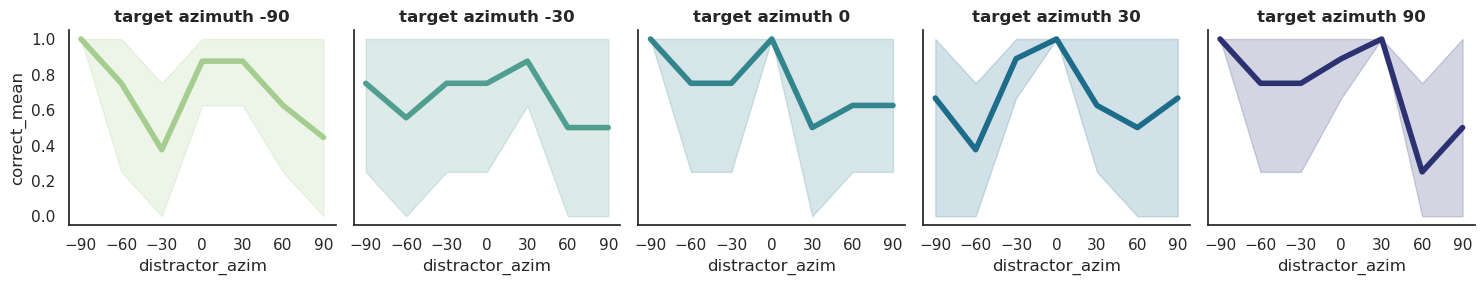

In [ ]:
g = sns.relplot(data=grouped_results[(grouped_results.target_elev == 0) & (grouped_results.distractor_elev == 0)],
            x="distractor_azim", y="correct_mean", col="target_azim", hue="target_azim",
            kind="line", palette="crest", linewidth=4, zorder=5,
            height=3, aspect=1, legend=False,
        )
g.set_titles("target azimuth {col_name}", fontweight="bold")
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0., 1.1, 0.2))
g.set_axis_labels("Distractor azimuth", "Prop. words correct")


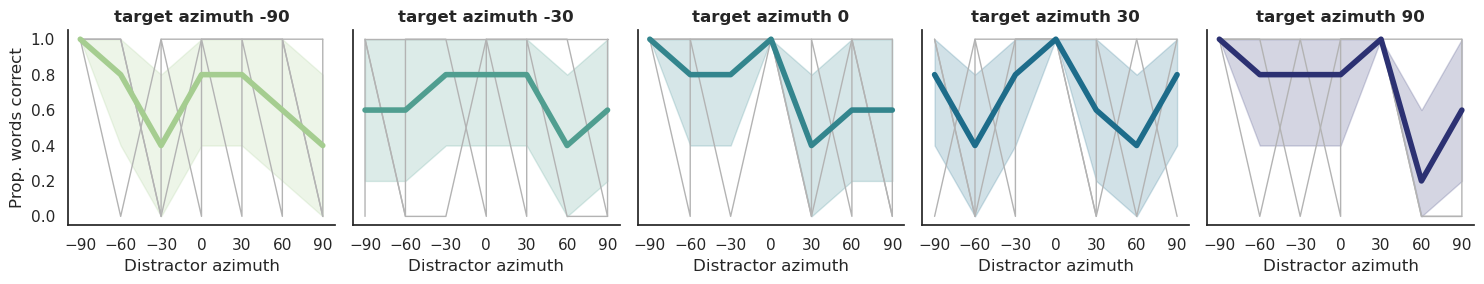

In [209]:
sns.set_theme(style="white")
# flights = sns.load_dataset("flights")

to_plot = results_df[(results_df.target_elev == 0) & (results_df.distractor_elev == 0) & (results_df.abs_target_azim.isin([0,30,90]))]

g = sns.relplot(
    data=to_plot,
    x="distractor_azim", y="correct", col="target_azim", hue="target_azim",
    kind="line", palette="crest", linewidth=4, zorder=5,
    height=3, aspect=1, legend=False,
)

# Iterate over each subplot to customize further
for azim, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    # ax.text(0.9, 1, f"target azimuth {azim}", transform=ax.transAxes, fontweight="bold")

    # Plot every year's time series in the background
    sns.lineplot(
        data=to_plot[to_plot.target_azim == azim],
         x="distractor_azim", y="correct", units="participant",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )

# Reduce the frequency of the x axis ticks
# ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("target azimuth {col_name}", fontweight="bold")
g.set_axis_labels("Distractor azimuth", "Prop. words correct")
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0., 1.1, 0.2))


# g.tight_layout()

/tmp/ipykernel_2599678/1291297603.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['folded_distractor_azim'] = to_plot.distractor_azim


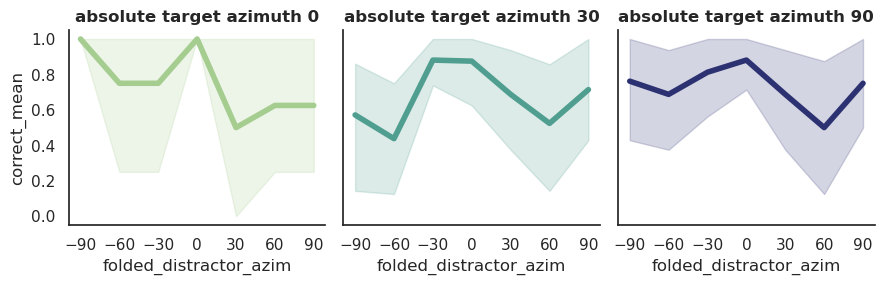

In [210]:
to_plot = grouped_results[(grouped_results.target_elev == 0) & (grouped_results.distractor_elev == 0)]
# fold left onto right for analysis 
to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 

g = sns.relplot(data=to_plot,
            x="folded_distractor_azim", y="correct_mean", col="abs_target_azim", hue="abs_target_azim",
            kind="line", palette="crest", linewidth=4, zorder=5,
            height=3, aspect=1, legend=False,
        )
g.set_titles("absolute target azimuth {col_name}", fontweight="bold")
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0., 1.1, 0.2))


In [201]:
results_df.index

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
             95,  96,  97,  98,  99, 100, 101, 102, 103, 104],
           dtype='int64', length=700)

/tmp/ipykernel_2599678/3887993186.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['folded_distractor_azim'] = to_plot.distractor_azim


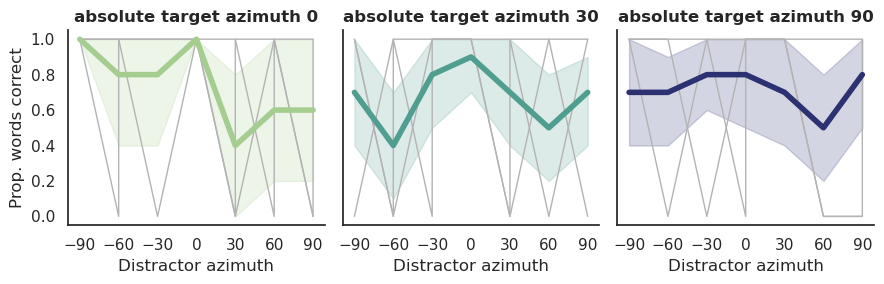

In [211]:

to_plot = results_df[(results_df.target_elev == 0) & (results_df.distractor_elev == 0)]# & (results_df.abs_target_azim.isin([0,30,90]))]

# fold left onto right for analysis 
to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 

sns.set_theme(style="white")
# flights = sns.load_dataset("flights")

g = sns.relplot(
    data=to_plot,
    x="folded_distractor_azim", y="correct",  col="abs_target_azim", hue="abs_target_azim",
    kind="line", palette="crest", linewidth=4, zorder=5,
    height=3, aspect=1, legend=False,
)

# Iterate over each subplot to customize further
for azim, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    # ax.text(0.9, 1, f"target azimuth {azim}", transform=ax.transAxes, fontweight="bold")

    # Plot every participant's data in the background
    sns.lineplot(
        data=to_plot[to_plot.target_azim == azim],
         x="distractor_azim", y="correct", units="participant",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )

# Reduce the frequency of the x axis ticks
# ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("absolute target azimuth {col_name}", fontweight="bold")
g.set_axis_labels("Distractor azimuth", "Prop. words correct")
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0., 1.1, 0.2))


# g.tight_layout()

/tmp/ipykernel_2599678/3076364442.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot["abs_elev_delta"] = to_plot.elev_delta.abs()


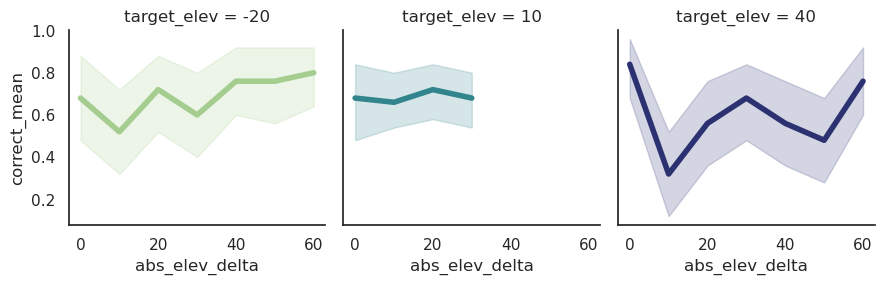

In [215]:
to_plot = grouped_results[(grouped_results.target_azim == grouped_results.distractor_azim) & (grouped_results.target_elev != 0)]
to_plot["abs_elev_delta"] = to_plot.elev_delta.abs()

sns.relplot(data=to_plot,
            x="abs_elev_delta", y="correct_mean", col="target_elev", hue="target_elev",
            kind="line", palette="crest", linewidth=4, zorder=5,
            height=3, aspect=1, legend=False,
        )

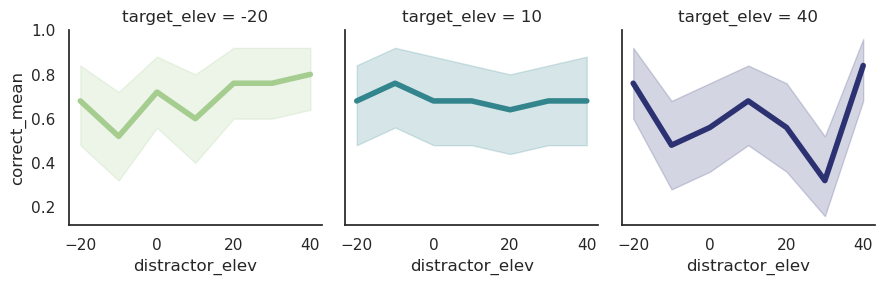

In [182]:
sns.relplot(data=grouped_results[(grouped_results.target_azim == grouped_results.distractor_azim) & (grouped_results.target_elev != 0)],
            x="distractor_elev", y="correct_mean", col="target_elev", hue="target_elev",
            kind="line", palette="crest", linewidth=4, zorder=5,
            height=3, aspect=1, legend=False,
        )

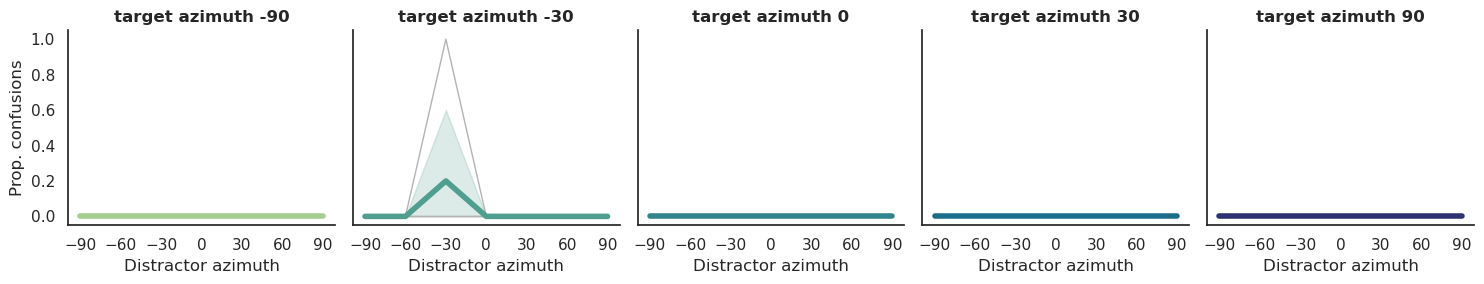

In [184]:
sns.set_theme(style="white")
# flights = sns.load_dataset("flights")

to_plot = results_df[(results_df.target_elev == 0) & (results_df.distractor_elev == 0)]

g = sns.relplot(
    data=to_plot,
    x="distractor_azim", y="confusions", col="target_azim", hue="target_azim",
    kind="line", palette="crest", linewidth=4, zorder=5,
    height=3, aspect=1, legend=False,
)

# Iterate over each subplot to customize further
for azim, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    # ax.text(0.9, 1, f"target azimuth {azim}", transform=ax.transAxes, fontweight="bold")

    # Plot every year's time series in the background
    sns.lineplot(
        data=to_plot[to_plot.target_azim == azim],
         x="distractor_azim", y="confusions", units="participant",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )

# Reduce the frequency of the x axis ticks
# ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("target azimuth {col_name}", fontweight="bold")
g.set_axis_labels("Distractor azimuth", "Prop. confusions")
g.set(xticks=np.arange(-90, 91, 30), yticks=np.arange(0., 1.1, 0.2))

# g.tight_layout()

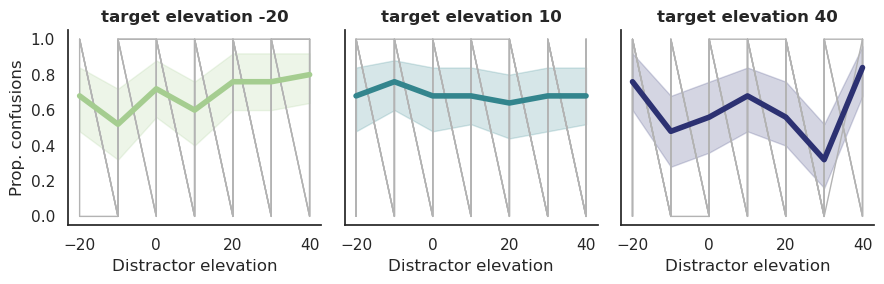

In [186]:
# flights = sns.load_dataset("flights")

to_plot = results_df[(results_df.target_azim == results_df.distractor_azim) & (results_df.target_elev != 0 )]

g = sns.relplot(
    data=to_plot,
    x="distractor_elev", y="correct", col="target_elev", hue="target_elev",
    kind="line", palette="crest", linewidth=4, zorder=5,
    height=3, aspect=1, legend=False,
)

# Iterate over each subplot to customize further
for elev, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    # ax.text(0.9, 1, elev, transform=ax.transAxes, fontweight="bold")

    # Plot every year's time series in the background
    sns.lineplot(
        data=to_plot[to_plot.target_elev == elev],
         x="distractor_elev", y="correct", units="participant",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )

# Reduce the frequency of the x axis ticks
# ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("target elevation {col_name}", fontweight="bold")
g.set_axis_labels("Distractor elevation", "Prop. confusions")
# g.set(xticks=np.arange(-2, 91, 30), yticks=np.arange(0., 1.1, 0.2))

# g.tight_layout()

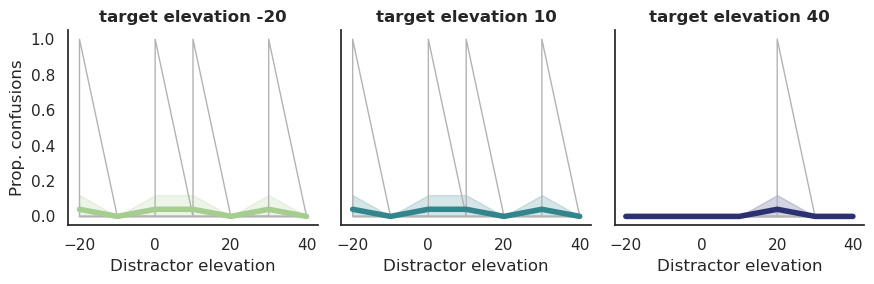

In [188]:
# flights = sns.load_dataset("flights")

to_plot = results_df[(results_df.target_azim == results_df.distractor_azim) & (results_df.target_elev != 0 )]

g = sns.relplot(
    data=to_plot,
    x="distractor_elev", y="confusions", col="target_elev", hue="target_elev",
    kind="line", palette="crest", linewidth=4, zorder=5,
    height=3, aspect=1, legend=False,
)

# Iterate over each subplot to customize further
for elev, ax in g.axes_dict.items():

    # Add the title as an annotation within the plot
    # ax.text(0.9, 1, elev, transform=ax.transAxes, fontweight="bold")

    # Plot every year's time series in the background
    sns.lineplot(
        data=to_plot[to_plot.target_elev == elev],
         x="distractor_elev", y="confusions", units="participant",
        estimator=None, color=".7", linewidth=1, ax=ax,
    )

# Reduce the frequency of the x axis ticks
# ax.set_xticks(ax.get_xticks()[::2])

# Tweak the supporting aspects of the plot
g.set_titles("target elevation {col_name}", fontweight="bold")
g.set_axis_labels("Distractor elevation", "Prop. confusions")
# g.set(xticks=np.arange(-2, 91, 30), yticks=np.arange(0., 1.1, 0.2))

# g.tight_layout()

In [ ]:

palette = {'same':'tab:blue', 'different':'tab:orange'}  
sns.set_style('whitegrid')
# 
# to_plot = results_df[(results_df.target_elev == 0) & (results_df.distractor_elev == 0)]
to_plot = grouped_results[(grouped_results.target_elev == 0)  & (grouped_results.distractor_elev == 0)]
to_plot.target_azim.unique()
to_plot['folded_distractor_azim'] = to_plot.distractor_azim 
to_plot.loc[to_plot.target_azim < 0, 'folded_distractor_azim'] = -1 * to_plot.distractor_azim 

g = sns.relplot(data=to_plot,
                palette=palette,
                 x='folded_distractor_azim', y='correct_mean', 
                  kind='line',  # hue='gender_cond',
                 col='abs_target_azim', col_wrap= 6, height=3.5)
g.set(xticks=np.arange(-90, 91, 30))



/tmp/ipykernel_2174119/4273144430.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['folded_distractor_azim'] = to_plot.distractor_azim
/tmp/ipykernel_2174119/4273144430.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(data=to_plot,


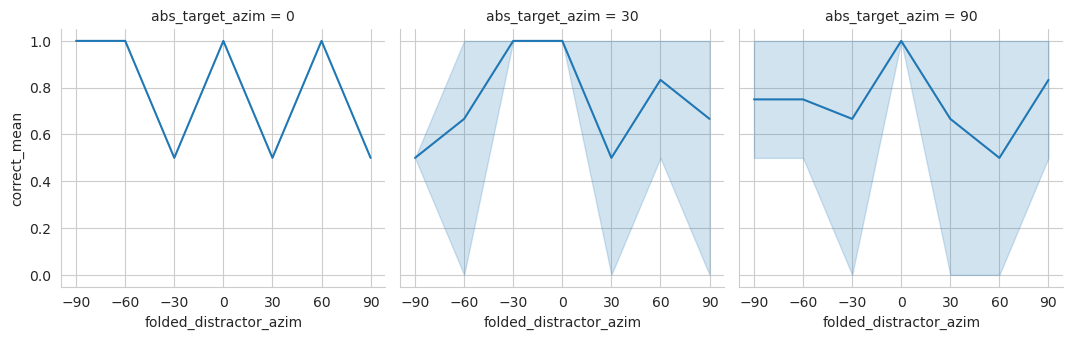

In [132]:

palette = {'same':'tab:blue', 'different':'tab:orange'}  
sns.set_style('whitegrid')

to_plot = results_df[(results_df.target_elev == 0) & (results_df.distractor_elev == 0)]
g = sns.relplot(data=to_plot,
                palette=palette,
                 x='distractor_azim', y='correct_mean', 
                 hue='gender_cond', kind='line', 
                 col='target_azim', col_wrap= 6, height=3.5)
g.set(xticks=np.arange(-90, 91, 30))



(0.0, 1.0)

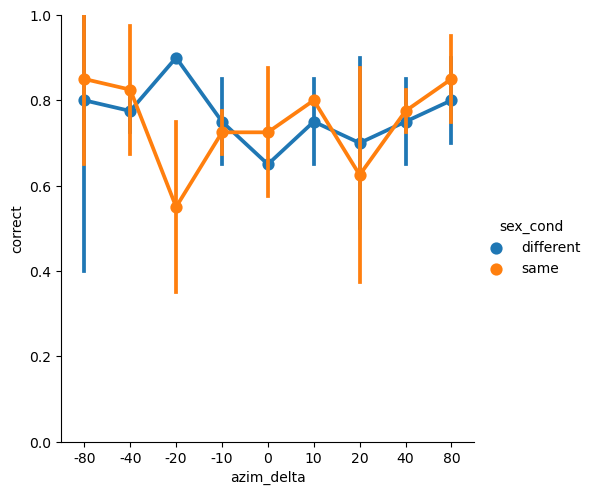

In [25]:
azim_summary_df = results_df.groupby(["part_id", "azim_delta", "sex_cond"]).correct.mean().reset_index()
sns.catplot(data=azim_summary_df, x='azim_delta', y='correct', kind='point', hue='sex_cond', errorbar=('se', 2))
plt.ylim(0, 1)

#### look at 0 elevation case 

(0.5, 1.0)

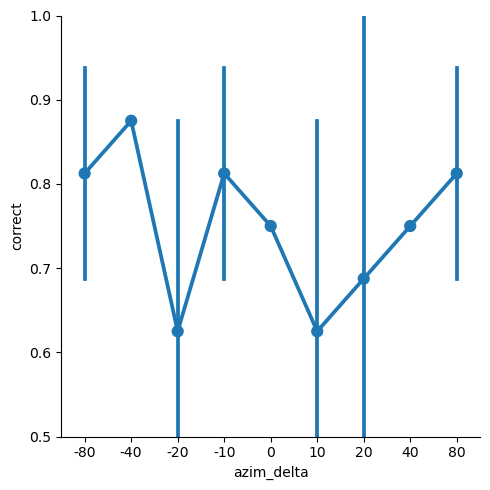

In [27]:
azim_summary_df = results_df[results_df.elev_delta == 0 ].groupby(["part_id", "azim_delta"]).correct.mean().reset_index()
sns.catplot(data=azim_summary_df, x='azim_delta', y='correct', kind='point', errorbar=('se',2))
plt.ylim(.5, 1)

## Accuracy by elevation (average over azimuth)

(0.5, 1.0)

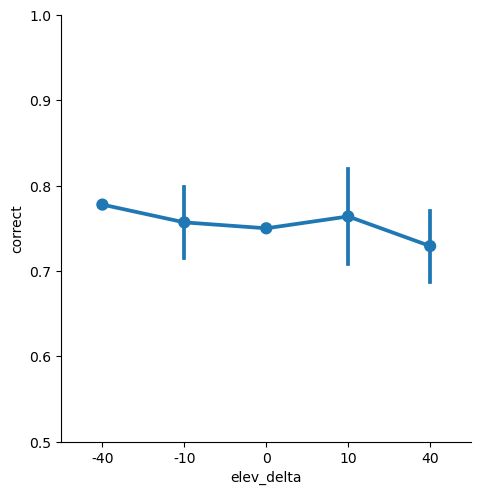

In [29]:
elev_summary_df = results_df.groupby(["part_id", "elev_delta"]).correct.mean().reset_index()
sns.catplot(data=elev_summary_df, x='elev_delta', y='correct', kind='point', errorbar=('se',2))
plt.ylim(0.5,1)

(0.5, 1.0)

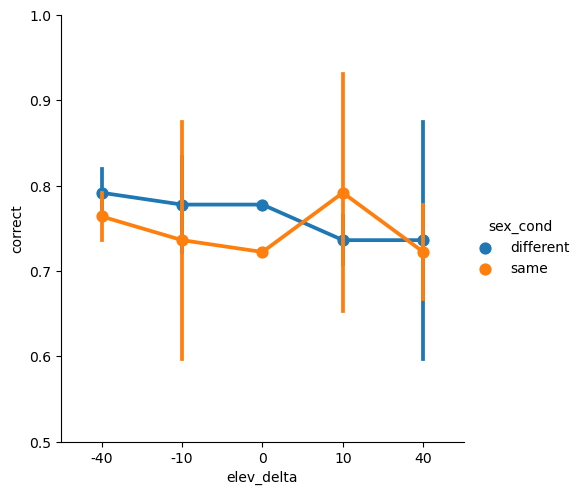

In [31]:
elev_summary_df = results_df.groupby(["part_id", "elev_delta", "sex_cond"]).correct.mean().reset_index()
sns.catplot(data=elev_summary_df, x='elev_delta', y='correct', kind='point', hue = "sex_cond", errorbar=('se',2))
plt.ylim(0.5,1)

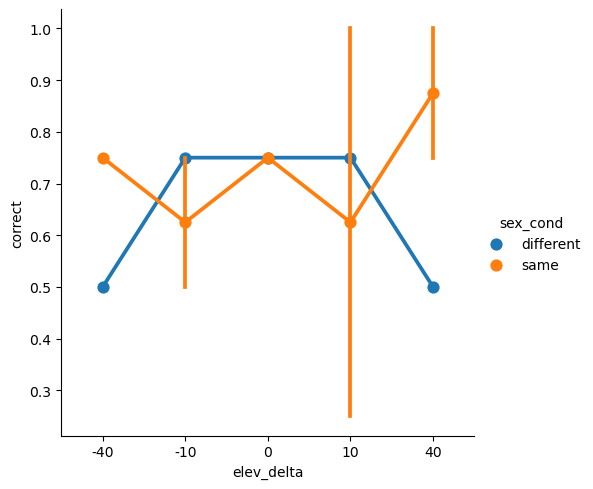

In [38]:
elev_summary_df = results_df[results_df.azim_delta ==0 ].groupby(["part_id",  "elev_delta", "sex_cond"]).correct.mean().reset_index()
sns.catplot(data=elev_summary_df, x='elev_delta', y='correct', kind='point',
             hue='sex_cond',  errorbar=('se'))
# plt.ylim(0.5,1)

## Across hemifield 

In [40]:
results_df[results_df.crossed == True]

,rt,response,correct_response,trial_num,trial_index,time_elapsed,correct,n_correct,n_incorrect,target_loc,distractor_loc,sex_cond,crossed,azim_delta,elev_delta,distractor_word,part_id,gender_cond
25,16511,death,those,25.0,50,323197,0.0,22.0,4.0,"(40, 30)","(-40, 30)",same,True,-80,0,islands,preston_pilot,female_female
30,8376,novel,novel,30.0,60,390123,1.0,26.0,5.0,"(50, 0)","(-30, 0)",different,True,-80,0,shows,preston_pilot,female_male
31,12096,provide,provide,31.0,62,403491,1.0,27.0,5.0,"(-30, 40)","(10, 0)",same,True,40,-40,birds,preston_pilot,female_female
38,9791,across,across,38.0,76,495580,1.0,32.0,7.0,"(30, 30)","(-50, 40)",same,True,-80,10,married,preston_pilot,male_male
39,20807,support,support,39.0,78,519329,1.0,33.0,7.0,"(10, 20)","(-70, -20)",same,True,-80,-40,government,preston_pilot,female_female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,8276,critics,alone,328.0,476,3027613,0.0,177.0,62.0,"(-60, 30)","(20, -10)",different,True,80,-40,information,ian_pilot,female_male
338,8140,letters,written,338.0,496,3155618,0.0,184.0,65.0,"(-50, -20)","(30, -20)",same,True,80,0,birds,ian_pilot,female_female
342,8758,research,research,342.0,504,3198182,1.0,187.0,66.0,"(10, 40)","(-30, 0)",different,True,-40,-40,between,ian_pilot,female_male
346,10037,recently,recently,346.0,512,3234930,1.0,191.0,66.0,"(-20, 20)","(60, -20)",same,True,80,-40,exist,ian_pilot,male_male


(0.5, 1.0)

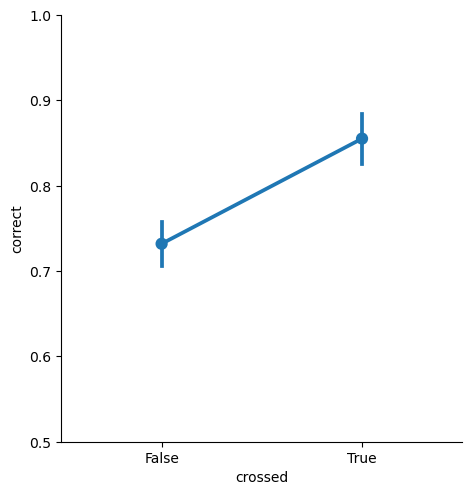

In [ ]:

crossed_summary_df = results_df.groupby(["part_id", "crossed", "sex_cond"]).correct.mean().reset_index()

sns.catplot(data=crossed_summary_df, x='crossed', y='correct', kind='point', errorbar=('se'))
plt.ylim(.5, 1)

(0.5, 1.0)

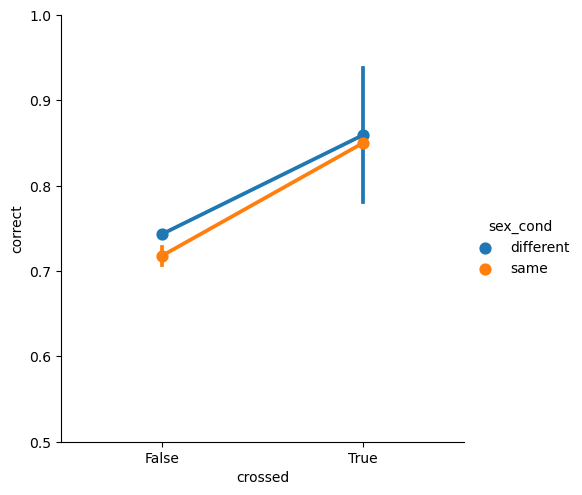

In [55]:

crossed_summary_df = results_df.groupby(["part_id", "crossed", "sex_cond"]).correct.mean().reset_index()

sns.catplot(data=crossed_summary_df, x='crossed', y='correct', kind='point', hue='sex_cond', errorbar=('se'))
plt.ylim(.5, 1)

In [57]:
results_df['abs_target_azim'] = results_df['target_azim'].abs()
results_df['target_on_periph'] = results_df['abs_target_azim'] >= 30

In [63]:
results_df

,rt,response,correct_response,trial_num,trial_index,time_elapsed,correct,n_correct,n_incorrect,target_azim,...,distractor_elev,sex_cond,crossed,azim_delta,elev_delta,distractor_word,part_id,gender_cond,abs_target_azim,target_on_periph
0,33746,students,students,0.0,0,33748,1.0,1.0,0.0,30,...,40,same,False,40,40,twenty,preston_pilot,male_male,30,True
1,10490,appear,appear,1.0,2,46805,1.0,2.0,0.0,-20,...,20,different,False,0,10,black,preston_pilot,male_female,20,False
2,9338,travel,travel,2.0,4,57269,1.0,3.0,0.0,-40,...,-10,different,False,-20,-40,worked,preston_pilot,female_male,40,True
3,10722,complete,complete,3.0,6,69002,1.0,4.0,0.0,0,...,20,different,False,40,10,complex,preston_pilot,male_female,0,False
4,8479,hundred,groups,4.0,8,78705,0.0,4.0,1.0,-90,...,20,different,False,80,40,players,preston_pilot,female_male,90,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,7310,living,living,355.0,530,3327958,1.0,198.0,68.0,40,...,20,different,False,40,40,entered,ian_pilot,male_female,40,True
356,9660,nothing,nothing,356.0,532,3338287,1.0,199.0,68.0,70,...,-10,different,False,-20,10,forward,ian_pilot,female_male,70,True
357,25705,reach,released,357.0,534,3365303,0.0,199.0,69.0,-90,...,-10,same,False,40,10,function,ian_pilot,female_female,90,True
358,7574,cover,cover,358.0,536,3373803,1.0,200.0,69.0,60,...,0,same,True,-80,0,least,ian_pilot,male_male,60,True


(0.5, 1.0)

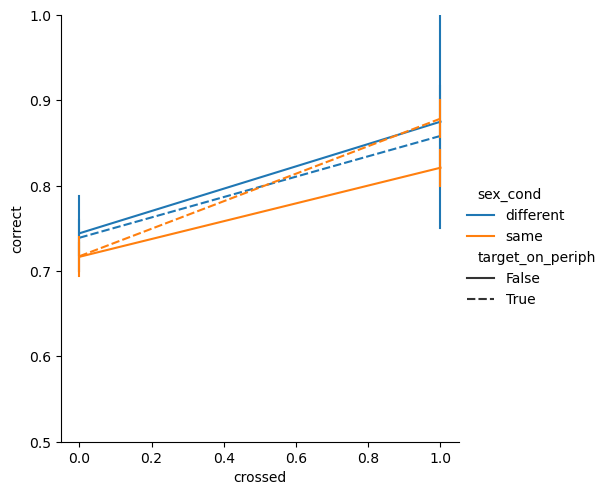

In [64]:

crossed_summary_df = results_df.groupby(["part_id", "crossed", "sex_cond", "target_on_periph"]).correct.mean().reset_index()

sns.relplot(data=crossed_summary_df, x='crossed', y='correct', kind='line', err_style='bars',
             hue='sex_cond', style='target_on_periph',  errorbar=('se'))
plt.ylim(.5, 1)


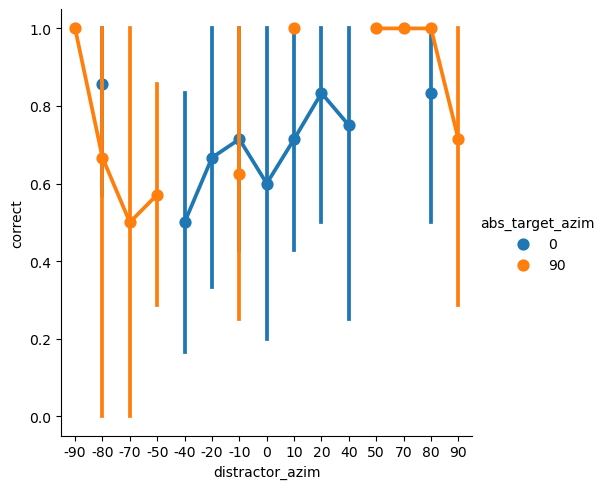

In [70]:
## Plot by position 

to_plot = results_df[results_df.abs_target_azim.isin([0, 90])]
sns.catplot(data=to_plot, x='distractor_azim', y='correct', kind='point', hue='abs_target_azim',)

